In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

from collections import Counter
from wordcloud import WordCloud

In [4]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
df = pd.read_csv(
    "/content/Customer Complaints in Banking new v1.csv",
    nrows=10000
)

print(df.shape)
print(df.head())
print(df.columns)

(10000, 11)
   Complaint ID Date submitted Date received Submitted via State  \
0       4848023     2021-10-24    2021-10-27      Referral    NY   
1       3621464     2020-04-24    2020-04-24           Web    FL   
2       5818349     2022-07-27    2022-07-27           Web    CA   
3       2473083     2017-05-01    2017-05-10   Postal mail    MD   
4       5820224     2022-07-27    2022-07-28      Referral    VA   

                                             Product  \
0                                           Mortgage   
1  Money transfer, virtual currency, or money ser...   
2  Credit reporting, credit repair services, or o...   
3                                    Debt collection   
4                        Credit card or prepaid card   

                                  Sub-product  \
0                  Conventional home mortgage   
1                   Refund anticipation check   
2                            Credit reporting   
3                   Private student loan debt 

In [7]:
df = df[["Issue", "Product"]]

df = df.dropna()

df = df.rename(columns={
    "Issue": "Complaint",
    "Product": "Category"
})

print("Prepared Banking Complaint Dataset")

print(df.head())

print("\nDataset Size")

print(df.shape)

print("\nComplaint Categories")

print(df["Category"].value_counts())

Prepared Banking Complaint Dataset
                                           Complaint  \
0  Applying for a mortgage or refinancing an exis...   
1                               Lost or stolen check   
2               Incorrect information on your report   
3                 False statements or representation   
4                               Closing your account   

                                            Category  
0                                           Mortgage  
1  Money transfer, virtual currency, or money ser...  
2  Credit reporting, credit repair services, or o...  
3                                    Debt collection  
4                        Credit card or prepaid card  

Dataset Size
(10000, 2)

Complaint Categories
Category
Checking or savings account                                                     3927
Credit card or prepaid card                                                     2692
Credit reporting, credit repair services, or other personal consumer rep

In [8]:
top_categories = df["Category"].value_counts().head(5).index

df = df[df["Category"].isin(top_categories)]

print("Selected Complaint Categories")

print(df["Category"].value_counts())

print("\nDataset Size")

print(df.shape)

Selected Complaint Categories
Category
Checking or savings account                                                     3927
Credit card or prepaid card                                                     2692
Credit reporting, credit repair services, or other personal consumer reports    1293
Mortgage                                                                         871
Money transfer, virtual currency, or money service                               655
Name: count, dtype: int64

Dataset Size
(9438, 2)


In [9]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Complaint"] = df["Complaint"].apply(clean_text)

print(df[["Complaint", "Cleaned_Complaint"]].head())

                                           Complaint  \
0  Applying for a mortgage or refinancing an exis...   
1                               Lost or stolen check   
2               Incorrect information on your report   
4                               Closing your account   
5                              Getting a credit card   

                                 Cleaned_Complaint  
0  applying mortgage refinancing existing mortgage  
1                                lost stolen check  
2                     incorrect information report  
4                                  closing account  
5                              getting credit card  


In [10]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Complaint"])

y = df["Category"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [12]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [13]:
y_pred = model.predict(X_test)

print("Predicted Complaint Categories")

print(y_pred)

Predicted Complaint Categories
['Checking or savings account' 'Checking or savings account'
 'Money transfer, virtual currency, or money service' ...
 'Credit reporting, credit repair services, or other personal consumer reports'
 'Checking or savings account' 'Mortgage']


In [14]:
complaints = [

    "There is incorrect information on my credit report.",

    "My credit card account was closed without permission.",

    "The bank charged me the wrong amount for my loan.",

    "My mortgage application was rejected.",

    "A debt collector is asking me to pay the wrong amount."

]

clean_complaints = []

for complaint in complaints:

    clean_complaints.append(clean_text(complaint))

complaint_vector = vectorizer.transform(clean_complaints)

prediction = model.predict(complaint_vector)

for complaint, category in zip(complaints, prediction):

    print(complaint)

    print("Category :", category)

    print()

There is incorrect information on my credit report.
Category : Credit reporting, credit repair services, or other personal consumer reports

My credit card account was closed without permission.
Category : Credit card or prepaid card

The bank charged me the wrong amount for my loan.
Category : Money transfer, virtual currency, or money service

My mortgage application was rejected.
Category : Mortgage

A debt collector is asking me to pay the wrong amount.
Category : Money transfer, virtual currency, or money service



In [15]:
issue_count = df["Complaint"].value_counts()

print("Top 10 Frequent Banking Issues")

print(issue_count.head(10))

Top 10 Frequent Banking Issues
Complaint
Managing an account                                                                 2269
Problem with a purchase shown on your statement                                      774
Incorrect information on your report                                                 732
Closing an account                                                                   495
Opening an account                                                                   468
Problem with a lender or other company charging your account                         459
Trouble during payment process                                                       379
Fraud or scam                                                                        372
Getting a credit card                                                                324
Problem with a credit reporting company's investigation into an existing problem     322
Name: count, dtype: int64


In [16]:
all_words = " ".join(df["Cleaned_Complaint"])

word_list = all_words.split()

word_freq = Counter(word_list)

print("Top 10 Common Words")

print(word_freq.most_common(10))

Top 10 Common Words
[('account', 3957), ('problem', 2786), ('managing', 2271), ('report', 1045), ('purchase', 966), ('closing', 851), ('shown', 774), ('statement', 774), ('incorrect', 733), ('information', 732)]


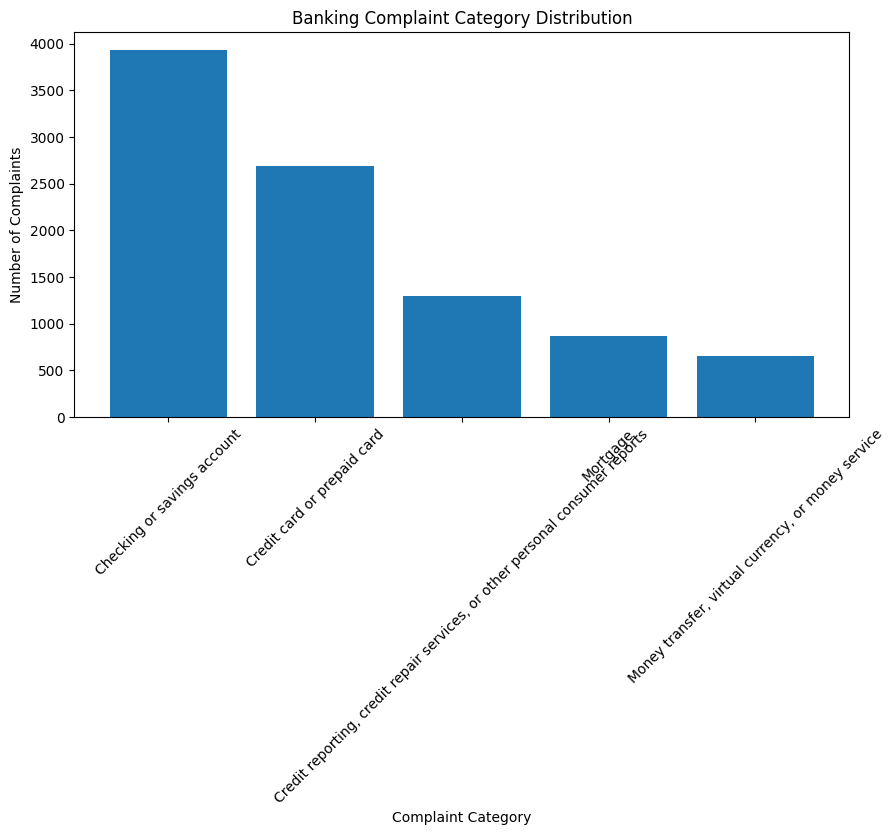

In [17]:
category_count = df["Category"].value_counts()

plt.figure(figsize=(10,5))

plt.bar(category_count.index, category_count.values)

plt.title("Banking Complaint Category Distribution")

plt.xlabel("Complaint Category")

plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)

plt.show()

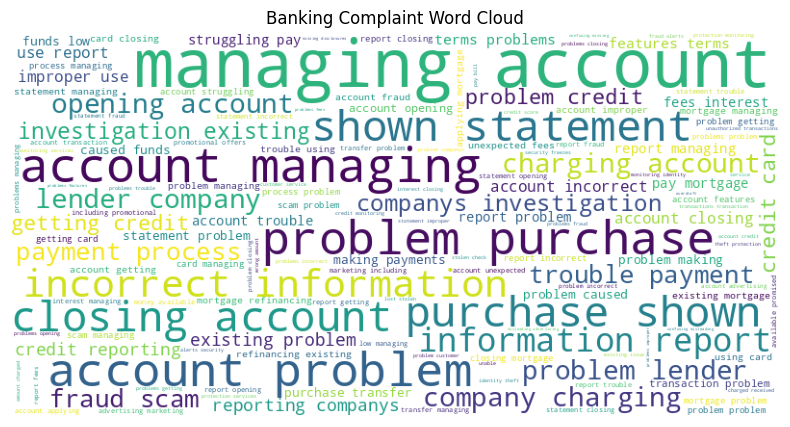

In [18]:
wordcloud = WordCloud(

    width=800,

    height=400,

    background_color="white"

).generate(all_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Banking Complaint Word Cloud")

plt.show()

In [19]:
print("Banking Complaint Analysis Report")

print("-----------------------------------")

print("Total Complaints :", len(df))

print("\nComplaint Categories")

print(category_count)

print("\nTop Banking Issues")

print(issue_count.head(10))

print("\nTop Keywords")

print(word_freq.most_common(10))

print("\nRecommendation")

print("The bank should focus on the most frequently reported customer issues and improve complaint resolution processes for high-volume categories. Faster issue identification and automated complaint categorization can help customer support teams respond more efficiently.")

Banking Complaint Analysis Report
-----------------------------------
Total Complaints : 9438

Complaint Categories
Category
Checking or savings account                                                     3927
Credit card or prepaid card                                                     2692
Credit reporting, credit repair services, or other personal consumer reports    1293
Mortgage                                                                         871
Money transfer, virtual currency, or money service                               655
Name: count, dtype: int64

Top Banking Issues
Complaint
Managing an account                                                                 2269
Problem with a purchase shown on your statement                                      774
Incorrect information on your report                                                 732
Closing an account                                                                   495
Opening an account                    